In [7]:
# 01_generate_skew_and_coords.py
import os, re
import numpy as np
import pandas as pd
from mt_metadata.transfer_functions import TF

def get_sitename(edi_path):
    with open(edi_path, "r", errors="ignore") as f:
        for line in f:
            if "SITENAME" in line.upper():
                return line.split("=")[1].strip().strip('"')
    return os.path.basename(edi_path).split(".")[0]

def parse_dms(value):
    try:
        parts = value.strip().split(":")
        d, m, s = float(parts[0]), float(parts[1]), float(parts[2])
        sign = -1 if d < 0 else 1
        return sign * (abs(d) + m/60 + s/3600)
    except:
        try:
            return float(value)
        except:
            return np.nan

def extract_lat_lon(edi_path):
    lat, lon = np.nan, np.nan
    with open(edi_path, "r", errors="ignore") as f:
        for raw in f:
            line = raw.strip()
            u = line.upper()
            if u.startswith("LAT="):
                lat = parse_dms(line.split("=",1)[1])
            if u.startswith("LONG=") or u.startswith("LON="):
                lon = parse_dms(line.split("=",1)[1])
            if u.startswith("REFLAT=") and np.isnan(lat):
                lat = parse_dms(line.split("=",1)[1])
            if u.startswith("REFLONG=") and np.isnan(lon):
                lon = parse_dms(line.split("=",1)[1])
    return lat, lon

def sanitize_edi(edi_path):
    with open(edi_path, "r", errors="ignore") as f:
        lines = f.readlines()
    cleaned = []
    for line in lines:
        if line.strip().startswith(">!"):
            cleaned.append(line); continue
        line = re.sub(r"\*+", " -9999 ", line)
        line = re.sub(r"(?<![0-9eE+\-])0\.0(?![0-9eE+\-])", " -9999 ", line)
        cleaned.append(line)
    return "".join(cleaned)

def compute_skew(edi_path):
    try:
        txt = sanitize_edi(edi_path)
        tmpfile = "_tmp_clean.edi"
        with open(tmpfile, "w", errors="ignore") as f:
            f.write(txt)
        tf = TF(); tf.read(fn=tmpfile)
        Z = np.array(tf.impedance.data, dtype=float)
        Z[Z == -9999] = np.nan
        Zxx, Zxy, Zyx, Zyy = Z[:,0,0], Z[:,0,1], Z[:,1,0], Z[:,1,1]
        skew = np.abs(Zxx + Zyy) / np.abs(Zxy - Zyx)
        skew = skew[np.isfinite(skew)]
        return np.nanmean(skew) if len(skew)>0 else np.nan
    except Exception:
        return np.nan

# Main
folder = "../data/all_station_EDI_data"  # update if needed
records = []
for fname in sorted(os.listdir(folder)):
    if not fname.lower().endswith(".edi"): continue
    path = os.path.join(folder, fname)
    site = os.path.basename(path).replace(".edi", "")
    lat, lon = extract_lat_lon(path)
    skew_val = compute_skew(path)
    records.append((site, fname, skew_val, lat, lon))

df = pd.DataFrame(records, columns=["Site","File","Skew","Lat","Lon"])
df["Is1D"] = df["Skew"] < 0.2
df = df.sort_values("Skew").reset_index(drop=True)
out = "each_file_skew_classification.csv"
df.to_csv(out, index=False)
print("Wrote", out)


/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1483125785.py:61: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1483125785.py:61: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1483125785.py:61: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1483125785.py:61: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1483125785.py:61: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impe

Wrote each_file_skew_classification.csv


In [4]:
# 02_compute_determinant.py
import os, re, numpy as np, pandas as pd
from mt_metadata.transfer_functions import TF

mu0 = 4.0 * np.pi * 1e-7

def sanitize_edi(edi_path):
    with open(edi_path, "r", errors="ignore") as f:
        lines = f.readlines()
    cleaned=[]
    for line in lines:
        if line.strip().startswith(">!"):
            cleaned.append(line); continue
        line = re.sub(r"\*+", " -9999 ", line)
        line = re.sub(r"(?<![0-9eE+\-])0\.0(?![0-9eE+\-])", " -9999 ", line)
        cleaned.append(line)
    return "".join(cleaned)

def get_sitename(edi_path):
    with open(edi_path,"r",errors="ignore") as f:
        for line in f:
            if "SITENAME" in line.upper():
                return line.split("=")[1].strip().strip('"')
    return os.path.basename(edi_path).split(".")[0]

def read_tf_from_edi(edi_path):
    txt = sanitize_edi(edi_path)
    tmpfile = "_tmp_clean.edi"
    with open(tmpfile,"w",errors="ignore") as f:
        f.write(txt)
    tf = TF(); tf.read(fn=tmpfile)
    return tf

def extract_periods(tf):
    if hasattr(tf,"period"):
        return np.array(tf.period.data, dtype=float)
    if hasattr(tf,"periods"):
        return np.array(tf.periods.data, dtype=float)
    if hasattr(tf,"frequency"):
        return 1.0/np.array(tf.frequency.data, dtype=float)
    if hasattr(tf,"frequencies"):
        return 1.0/np.array(tf.frequencies.data, dtype=float)
    Z = np.array(tf.impedance.data); return np.arange(1, Z.shape[0]+1).astype(float)

out_dir = "determinant_per_station"
os.makedirs(out_dir, exist_ok=True)

edi_folder = "../data/all_station_EDI_data"  # same folder
for fname in sorted(os.listdir(edi_folder)):
    if not fname.lower().endswith(".edi"): continue
    path = os.path.join(edi_folder, fname)
    try:
        tf = read_tf_from_edi(path)
    except Exception as e:
        print("fail read", fname, e); continue

    periods = extract_periods(tf)
    Z = np.array(tf.impedance.data, dtype=complex)
    Zxx = Z[:,0,0]; Zxy = Z[:,0,1]; Zyx = Z[:,1,0]; Zyy = Z[:,1,1]

    bad = np.isclose(Zxx.real, -9999) | np.isclose(Zxy.real, -9999) | np.isclose(Zyx.real, -9999) | np.isclose(Zyy.real, -9999)
    Zxx[bad] = np.nan+1j*np.nan; Zxy[bad]=np.nan+1j*np.nan; Zyx[bad]=np.nan+1j*np.nan; Zyy[bad]=np.nan+1j*np.nan

    Zdet = np.sqrt(Zxy * Zyx - Zxx * Zyy)
    omega = 2.0 * np.pi / periods
    omega = np.where(periods>0, omega, np.nan)
    rho = (np.abs(Zdet)**2) / (mu0 * omega)
    phase = np.angle(Zdet, deg=True)

    n = min(len(periods), len(rho))
    periods = periods[:n]; Zdet = Zdet[:n]; rho = rho[:n]; phase = phase[:n]

    site = get_sitename(path)
    safe_name = site.replace(" ", "_").replace(",","").replace("/","_")
    out_csv = os.path.join(out_dir, f"{safe_name}_det.csv")
    pd.DataFrame({
        "period_s": periods,
        "Zdet_real": np.real(Zdet),
        "Zdet_imag": np.imag(Zdet),
        "rho_det": rho,
        "phase_det_deg": phase
    }).to_csv(out_csv, index=False)
    print("Wrote", out_csv)


Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determinant_per_station/Barotse_Basin_Western_Province_Zambia_det.csv
Wrote determ

In [5]:
# 03_make_summary_for_QGIS.py
import os, glob, numpy as np, pandas as pd

station_meta = pd.read_csv("each_file_skew_classification.csv")
station_meta["Site"] = station_meta["Site"].astype(str)

PER_STATION_DIR = "determinant_per_station"
station_csvs = sorted(glob.glob(os.path.join(PER_STATION_DIR,"*_det.csv")))
target_periods = np.array([1.0, 10.0, 100.0])
records = []

def site_from_filename(fname):
    base = os.path.basename(fname).replace("_det.csv","")
    return base.replace("_"," ").strip()

for p in station_csvs:
    site = site_from_filename(p)        # must match Site in station_meta
    df = pd.read_csv(p)
    periods = df['period_s'].values; rho = df['rho_det'].values
    valid = np.isfinite(periods) & np.isfinite(rho)
    if valid.sum() < 4: continue
    logT = np.log10(periods[valid]); logrho = np.log10(rho[valid])
    interp = {}
    for tp in target_periods:
        if (periods[valid].min() <= tp <= periods[valid].max()):
            interp_val = 10**np.interp(np.log10(tp), logT, logrho)
        else:
            interp_val = np.nan
        interp[f"rho_T{int(tp)}s"] = interp_val
    median_logrho = np.nanmedian(logrho)
    median_rho = 10**median_logrho if np.isfinite(median_logrho) else np.nan
    records.append({
        "Site": site,
        "MedianLogRho": float(median_logrho) if np.isfinite(median_logrho) else np.nan,
        "MedianRho": float(median_rho),
        "rho_T1s": interp["rho_T1s"],
        "rho_T10s": interp["rho_T10s"],
        "rho_T100s": interp["rho_T100s"],
        "Nperiods": int(valid.sum())
    })

summary_df = pd.DataFrame(records)

# Merge coordinates from station_meta using 'Site' column.
merged_df = summary_df.merge(station_meta[["Site","Lat","Lon"]], on="Site", how="left")

# If merge produced NaNs because Site strings differ, attempt fallback match by filename token:
if merged_df["Lat"].isna().any():
    # try to match by removing punctuation and comparing lowercased tokens
    def norm(s): return str(s).lower().replace(",","").replace(".","").replace("_"," ").strip()
    station_meta["norm"] = station_meta["Site"].apply(norm)
    summary_df["norm"] = summary_df["Site"].apply(norm)
    merged_df = summary_df.merge(station_meta[["norm","Lat","Lon"]], on="norm", how="left")
    merged_df = merged_df.drop(columns=["norm"])

out = "determinant_station_summary_for_QGIS.csv"
merged_df.to_csv(out, index=False)
print("Wrote", out)


Wrote determinant_station_summary_for_QGIS.csv


/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1037838628.py:22: RuntimeWarning: divide by zero encountered in log10
  logT = np.log10(periods[valid]); logrho = np.log10(rho[valid])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1037838628.py:22: RuntimeWarning: divide by zero encountered in log10
  logT = np.log10(periods[valid]); logrho = np.log10(rho[valid])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1037838628.py:22: RuntimeWarning: divide by zero encountered in log10
  logT = np.log10(periods[valid]); logrho = np.log10(rho[valid])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1037838628.py:22: RuntimeWarning: divide by zero encountered in log10
  logT = np.log10(periods[valid]); logrho = np.log10(rho[valid])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/1037838628.py:22: RuntimeWarning: divide by zero encountered in log10
  logT = np.log10(periods[valid]); logrho = np.log10(rho[valid])


Saved QC grid to qc_grid.png


/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/2982218948.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/2982218948.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/2982218948.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/2982218948.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_52390/2982218948.py:27: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(periods[mask]); y = np.log10(rho[mask])
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/i

Wrote determinant_station_summary_with_slope.csv


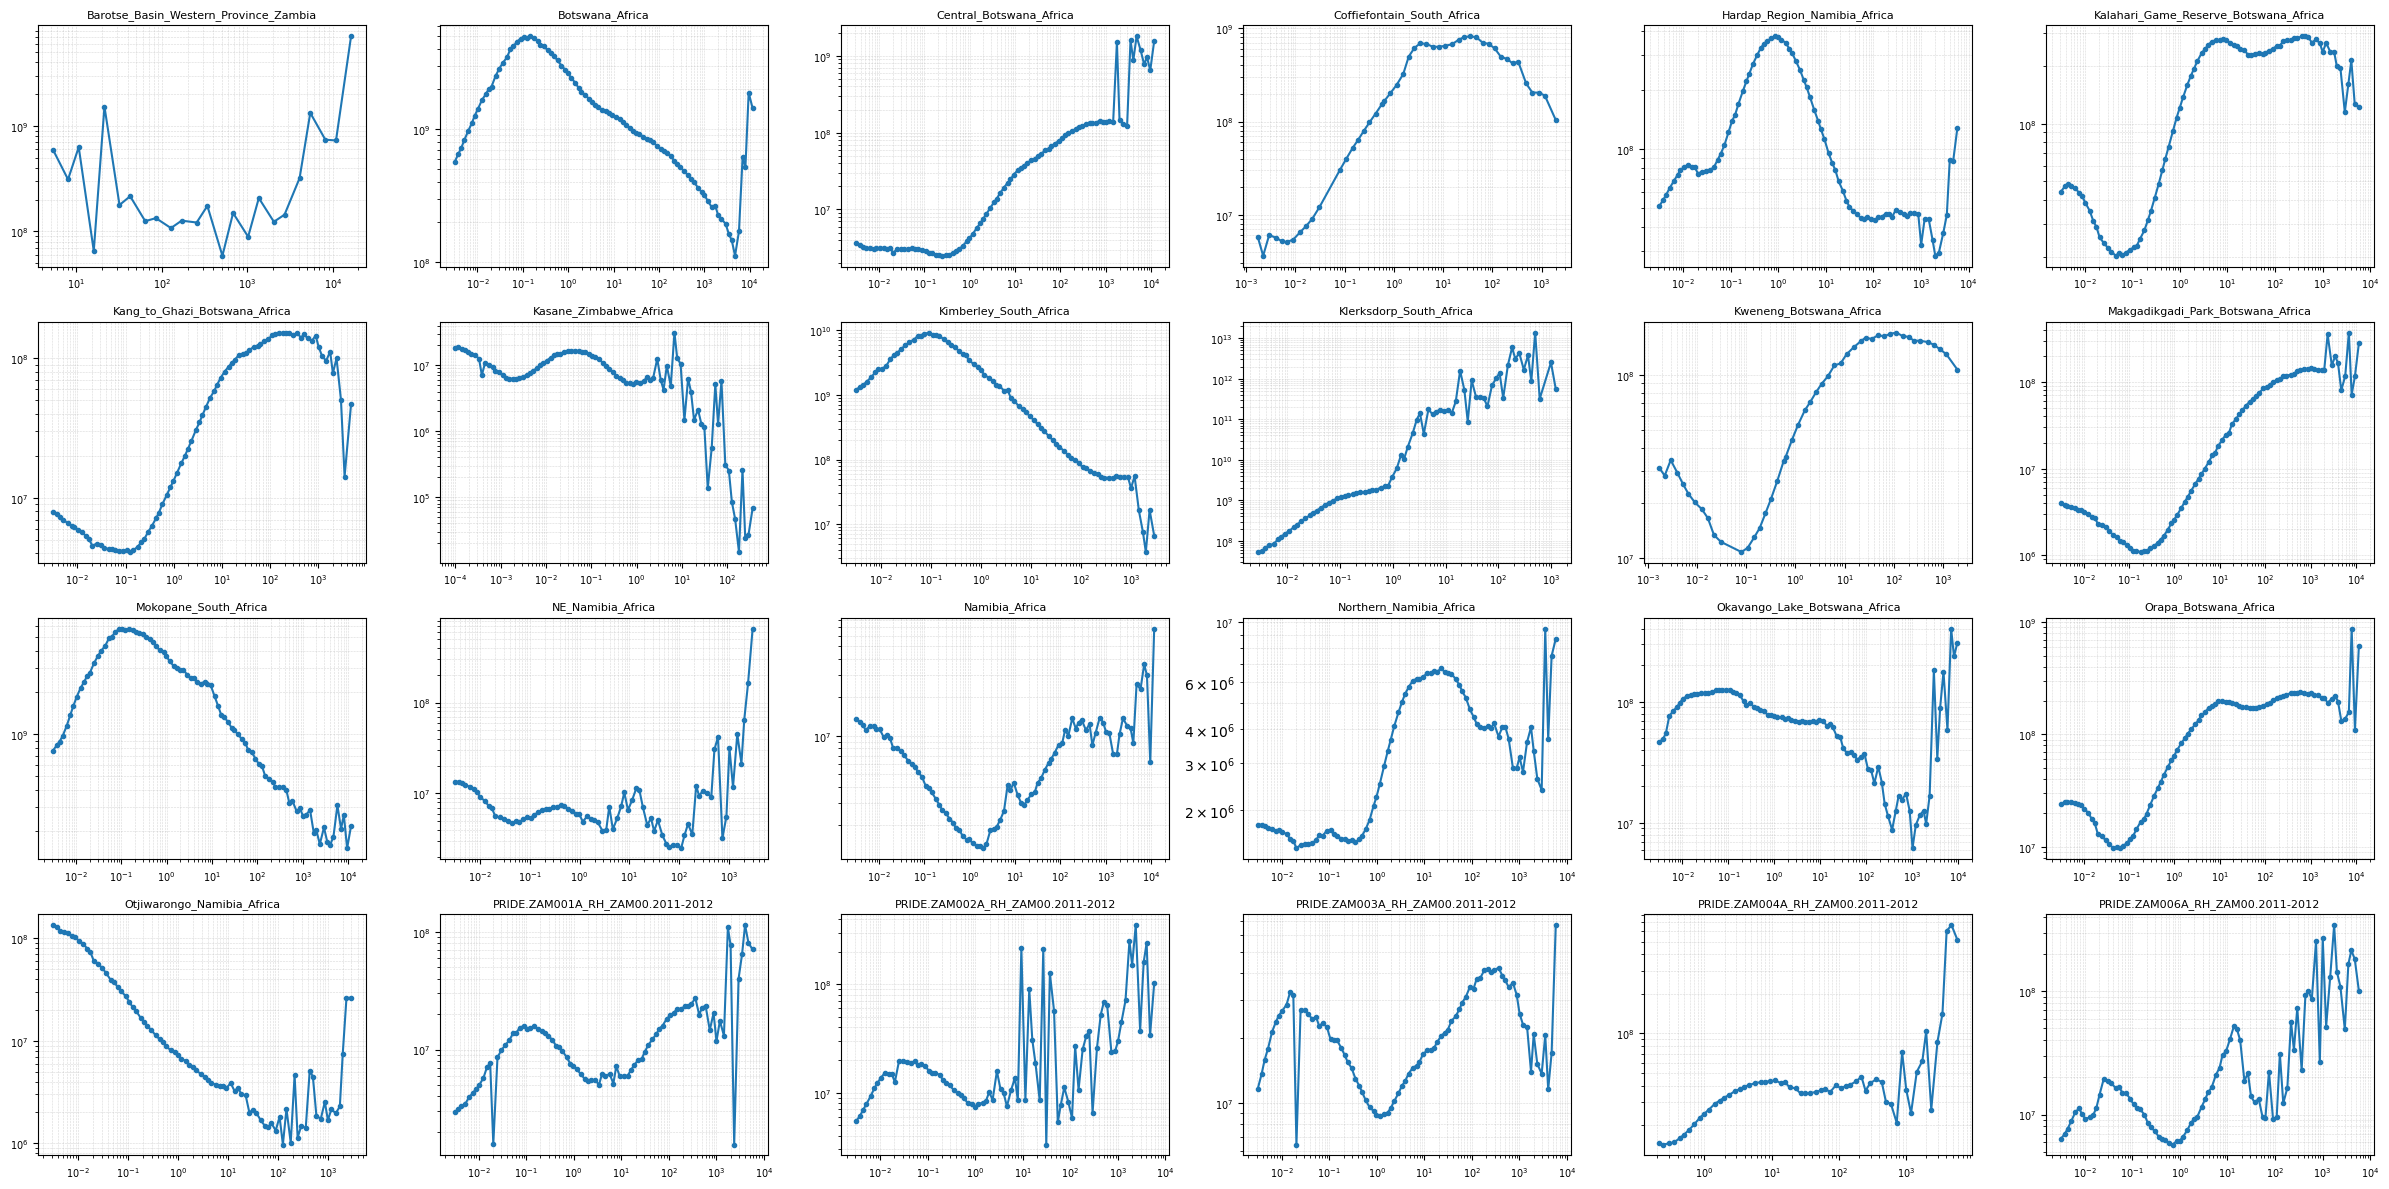

In [6]:
# 04_qc_plot_and_compute_slope.py
import os, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt

PER_STATION_DIR = "determinant_per_station"
station_csvs = sorted(glob.glob(os.path.join(PER_STATION_DIR,"*_det.csv")))

# quick grid plot
def plot_grid(csv_files, ncols=6, max_plots=24, save_png="qc_grid.png"):
    n = min(len(csv_files), max_plots)
    nrows = int(np.ceil(n/ncols))
    fig = plt.figure(figsize=(4*ncols,3*nrows))
    for i,f in enumerate(csv_files[:n]):
        df = pd.read_csv(f)
        periods = df['period_s']; rho = df['rho_det']
        ax = fig.add_subplot(nrows,ncols,i+1)
        ax.loglog(periods, rho, marker='o', markersize=3, linestyle='-')
        ax.set_title(os.path.basename(f).replace("_det.csv",""), fontsize=8)
        ax.grid(True, which='both', lw=0.4, ls='--', alpha=0.5)
        ax.tick_params(axis='both', labelsize=7)
    plt.tight_layout(); fig.savefig(save_png, dpi=200)
    print("Saved QC grid to", save_png)

def compute_slope_midband(periods, rho, pmin=1, pmax=100):
    mask = (periods>=pmin) & (periods<=pmax) & np.isfinite(rho)
    if mask.sum() < 4: return np.nan
    x = np.log10(periods[mask]); y = np.log10(rho[mask])
    return float(np.polyfit(x,y,1)[0])

plot_grid(station_csvs, ncols=6, max_plots=24)

# compute slopes and add to summary
summary = pd.read_csv("determinant_station_summary_for_QGIS.csv")
slopes = []
for f in station_csvs:
    site = os.path.basename(f).replace("_det.csv","").replace("_"," ").strip()
    df = pd.read_csv(f)
    s = compute_slope_midband(df['period_s'].values, df['rho_det'].values)
    slopes.append((site,s))
sdf = pd.DataFrame(slopes, columns=["Site","Slope_mid_1_100s"])
outdf = summary.merge(sdf, on="Site", how="left")
outdf.to_csv("determinant_station_summary_with_slope.csv", index=False)
print("Wrote determinant_station_summary_with_slope.csv")
